# **CA3 - Reinforcement Learning**

In [ ]:
# !pip install -i https://mirror-pypi.runflare.com/simple "gym==0.26.2" "numpy<2" pygame matplotlib

In [1]:
import gym
import math
import numpy as np
from collections import deque
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


### **PART 1: AGENT IMPLEMENTATION**

In [2]:
if not hasattr(np, "bool8"):
    np.bool8 = np.bool_

/var/folders/33/1_9c8vl1123ffv0k7k3c_44c0000gn/T/ipykernel_25380/920200510.py:1: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  if not hasattr(np, "bool8"):


In [11]:
class QLearningAgent:
    def __init__(
        self,
        env,
        buckets=(40, 40),
        alpha=0.05,
        gamma=0.99,
        epsilon_strategy='exponential',
        episodes=100000,
        seed=400
    ):
        self.env = env
        self.buckets = buckets
        self.alpha = alpha
        self.gamma = gamma
        self.episodes = episodes
        self.epsilon_strategy = epsilon_strategy
        self.seed = seed

        self.rng = np.random.default_rng(seed)
        self.env.action_space.seed(seed)

        self.lower_bounds = self.env.observation_space.low
        self.upper_bounds = self.env.observation_space.high

        self.Q_table = np.zeros(self.buckets + (self.env.action_space.n,))

        self.threshold = self.env.spec.reward_threshold
        print('threshold:', self.threshold)

    def reset_env(self, episode=0):
        reset_result = self.env.reset(seed=self.seed + episode)

        if isinstance(reset_result, tuple):
            obs = reset_result[0]
        else:
            obs = reset_result

        return obs

    def discretize_state(self, obs):
        ratios = (obs - self.lower_bounds) / (self.upper_bounds - self.lower_bounds)
        new_obs = np.int32(np.round(ratios * (np.array(self.buckets) - 1)))
        new_obs = np.clip(new_obs, 0, np.array(self.buckets) - 1)
        return tuple(new_obs)

    def choose_action(self, state, epsilon):
        if self.rng.random() < epsilon:
            return self.env.action_space.sample()
        else:
            return np.argmax(self.Q_table[state])

    def get_epsilon(self, episode):
        min_eps = 0.01
        max_eps = 1.0
        
        if self.epsilon_strategy == 'constant':
            return 0.1
            
        elif self.epsilon_strategy == 'linear':
            decay_step = (max_eps - min_eps) / (self.episodes * 0.8)
            return max(min_eps, max_eps - decay_step * episode)
            
        elif self.epsilon_strategy == 'exponential':
            decay_rate = 5 / self.episodes
            return min_eps + (max_eps - min_eps) * np.exp(-decay_rate * episode)
            
        elif self.epsilon_strategy == 'logarithmic':
            decay_rate = np.log(episode + 1) / np.log(self.episodes + 1)
            return max(min_eps, max_eps * (1 - decay_rate))
            
        return min_eps


    def train(self):
        scores_window = deque(maxlen=100)
        scores_array = []
        avg_scores_array = []
        epsilons_array = []
        shaped_scores_array = []

        for episode in range(self.episodes):
            obs, _ = self.env.reset()
            state = self.discretize_state(obs)
            epsilon = self.get_epsilon(episode)
            epsilons_array.append(epsilon)
            
            done = False
            total_reward = 0
            
            while not done:
                action = self.choose_action(state, epsilon)
                next_obs, reward, terminated, truncated, _ = self.env.step(action)
                done = terminated or truncated
                
                next_state = self.discretize_state(next_obs)
                
                best_next_action = np.argmax(self.Q_table[next_state])
                td_target = reward + self.gamma * self.Q_table[next_state][best_next_action] * (not terminated)
                td_error = td_target - self.Q_table[state][action]
                self.Q_table[state][action] += self.alpha * td_error
                
                state = next_state
                total_reward += reward

            scores_array.append(total_reward)
            scores_window.append(total_reward)
            avg_scores_array.append(np.mean(scores_window))
            shaped_scores_array.append(total_reward)
            
            if episode % 1000 == 0 and episode > 0:
                print(f"Episode: {episode}, Average Score: {np.mean(scores_window):.2f}, epsilon:P{epsilon}")

            if len(scores_window) == 100 and np.mean(scores_window) >= -110.0:
                print(f"Threshold of -110.0 reached in {episode} episodes!")
                break

        return scores_array, avg_scores_array, epsilons_array, shaped_scores_array

    def evaluate(self, episodes=100):
        eval_scores = []
        
        for _ in range(episodes):
            obs, _ = self.env.reset()
            state = self.discretize_state(obs)
            done = False
            total_reward = 0
            
            while not done:
                action = np.argmax(self.Q_table[state])
                next_obs, reward, terminated, truncated, _ = self.env.step(action)
                done = terminated or truncated
                state = self.discretize_state(next_obs)
                total_reward += reward
                
            eval_scores.append(total_reward)
            
        return eval_scores


In [12]:
env = gym.make('MountainCar-v0')

visual_agent = QLearningAgent(
    env, 
    buckets=(40, 40), 
    epsilon_strategy='exponential', 
    episodes=500000,
    seed=400)

threshold: -110.0


In [5]:
def watch_agent(agent, episodes=5):
    env = gym.make("MountainCar-v0", render_mode="human")

    for episode in range(episodes):
        reset_result = env.reset(seed=agent.seed + 200000 + episode)

        if isinstance(reset_result, tuple):
            obs = reset_result[0]
        else:
            obs = reset_result

        state = agent.discretize_state(obs)
        done = False
        total_reward = 0

        while not done:
            action = np.argmax(agent.Q_table[state])

            step_result = env.step(action)

            if len(step_result) == 4:
                next_obs, reward, done, _ = step_result
            else:
                next_obs, reward, terminated, truncated, _ = step_result
                done = terminated or truncated

            state = agent.discretize_state(next_obs)
            total_reward += reward

        print(f"Episode {episode + 1} reward: {total_reward}")

    env.close()

In [ ]:
watch_agent(visual_agent, episodes=5)

### **PART 2: AGENT TRAINING**

In [13]:
scores, avg_scores, epsilons, shaped_scores = visual_agent.train()

/Users/mohammad/Library/Python/3.9/lib/python/site-packages/gym/utils/passive_env_checker.py:233: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  if not isinstance(terminated, (bool, np.bool8)):


Episode: 1000, Average Score: -200.00, epsilon:P0.9901493354116764
Episode: 2000, Average Score: -200.00, epsilon:P0.9803966865736877
Episode: 3000, Average Score: -200.00, epsilon:P0.970741078213023
Episode: 4000, Average Score: -200.00, epsilon:P0.9611815447608
Episode: 5000, Average Score: -200.00, epsilon:P0.9517171302557069
Episode: 6000, Average Score: -200.00, epsilon:P0.9423468882484062
Episode: 7000, Average Score: -200.00, epsilon:P0.9330698817068888
Episode: 8000, Average Score: -200.00, epsilon:P0.9238851829227694
Episode: 9000, Average Score: -200.00, epsilon:P0.9147918734185159
Episode: 10000, Average Score: -200.00, epsilon:P0.9057890438555999
Episode: 11000, Average Score: -200.00, epsilon:P0.896875793943563
Episode: 12000, Average Score: -200.00, epsilon:P0.888051232349986
Episode: 13000, Average Score: -200.00, epsilon:P0.8793144766113556
Episode: 14000, Average Score: -200.00, epsilon:P0.8706646530448178
Episode: 15000, Average Score: -200.00, epsilon:P0.862100896660

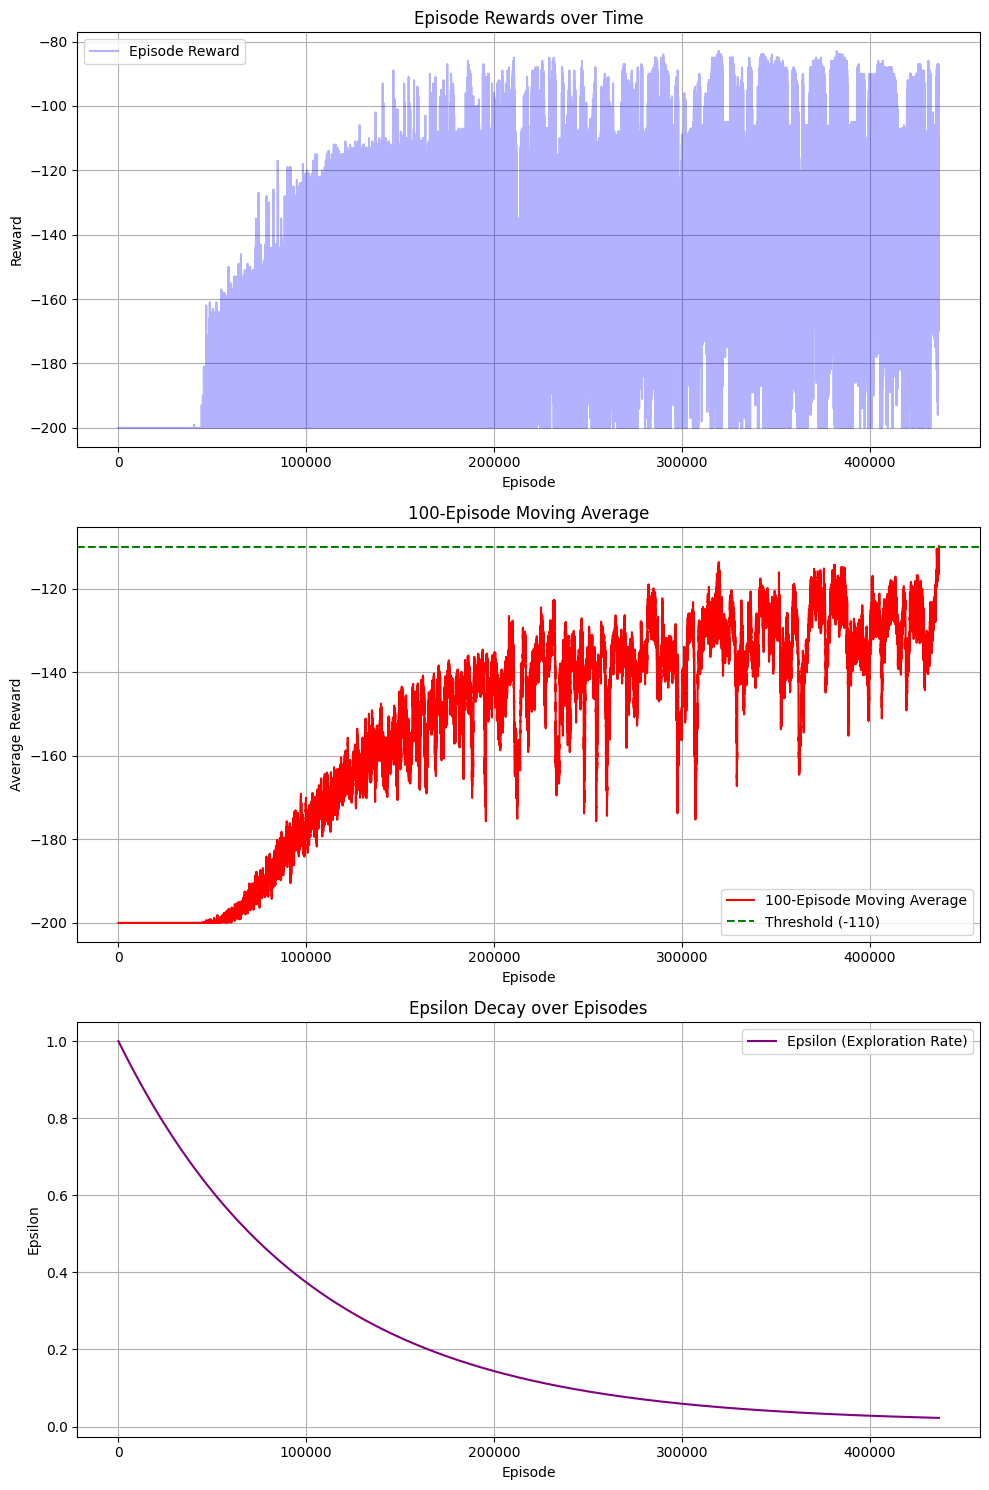

In [ ]:
import matplotlib.pyplot as plt



fig, axs = plt.subplots(3, 1, figsize=(10, 15))


axs[0].plot(scores, color='blue', alpha=0.3, label='Episode Reward')
axs[0].set_title('Episode Rewards over Time')
axs[0].set_xlabel('Episode')
axs[0].set_ylabel('Reward')
axs[0].legend()
axs[0].grid(True)


axs[1].plot(avg_scores, color='red', label='100-Episode Moving Average')
axs[1].axhline(y=-110, color='green', linestyle='--', label='Threshold (-110)')
axs[1].set_title('100-Episode Moving Average')
axs[1].set_xlabel('Episode')
axs[1].set_ylabel('Average Reward')
axs[1].legend()
axs[1].grid(True)


axs[2].plot(epsilons, color='purple', label='Epsilon (Exploration Rate)')
axs[2].set_title('Epsilon Decay over Episodes')
axs[2].set_xlabel('Episode')
axs[2].set_ylabel('Epsilon')
axs[2].legend()
axs[2].grid(True)

plt.tight_layout()
plt.show()


### Agent Training Analysis: Convergence, Stability, and Reward Density

**1. Exploration vs. Exploitation ($\epsilon$ Decay):**
The epsilon decay plot illustrates a smooth exponential decrease from $1.0$ down to near $0.0$ across approximately $450,000$ episodes. This schedule ensures that the agent primarily explores the state space during the initial $100,000$ episodes and progressively shifts towards exploiting its learned Q-values in the later stages.

**2. Reward Density and Raw Performance:**
The "Episode Rewards over Time" plot (light blue) shows the raw reward per episode. Up to episode $50,000$, the agent consistently fails, hitting the $-200$ penalty limit. As training progresses and $\epsilon$ decreases, the density of the plot shifts upwards. In the later half of training, there is a high concentration of rewards between $-160$ and $-80$, indicating that the agent successfully reaches the flag in a significantly lower number of steps.

**3. Convergence and Stability (Moving Average):**
The "100-Episode Moving Average" plot (red) is the primary indicator of learning. The upward trend from $-200$ clearly demonstrates that the agent is learning a valid policy to solve the MountainCar environment. However, the convergence is characterized by **high variance and instability**. The moving average fluctuates wildly, frequently dropping from $-120$ back down to $-160$ or lower. Although the agent occasionally touches or briefly surpasses the $-110$ threshold (green dashed line) near the end, it fails to maintain a stable performance above this line. This instability in a discretized Q-learning agent typically points to *state aliasing* (due to the bucket size) or the inherent difficulty of maintaining a stable policy without function approximation (like Deep Q-Networks).


### **PART 3: AGENT EVALUATION**

In [15]:
eval_scores = visual_agent.evaluate(episodes=100)

print("Evaluation without exploration")
print("Mean evaluation score:", np.mean(eval_scores))
print("Best evaluation score:", np.max(eval_scores))
print("Worst evaluation score:", np.min(eval_scores))

Evaluation without exploration
Mean evaluation score: -107.27
Best evaluation score: -92.0
Worst evaluation score: -166.0


In [ ]:
watch_agent(visual_agent, episodes=5)

### **PART 4: EPSILON STRATEGY AND DISCRETIZATION GRANUALITY EXPERIMENTS**

In [ ]:
import matplotlib.pyplot as plt

def plot_training_result(scores, avg_scores, epsilons, title):
 
    fig, axs = plt.subplots(3, 1, figsize=(10, 15))
    fig.suptitle(title, fontsize=16)

  
    axs[0].plot(scores, color='blue', alpha=0.3, label='Episode Reward')
    axs[0].set_title('Episode Rewards over Time')
    axs[0].set_xlabel('Episode')
    axs[0].set_ylabel('Reward')
    axs[0].legend()
    axs[0].grid(True)

   
    axs[1].plot(avg_scores, color='red', label='100-Episode Moving Average')
    axs[1].axhline(y=-110, color='green', linestyle='--', label='Threshold (-110)')
    axs[1].set_title('100-Episode Moving Average')
    axs[1].set_xlabel('Episode')
    axs[1].set_ylabel('Average Reward')
    axs[1].legend()
    axs[1].grid(True)

   
    axs[2].plot(epsilons, color='purple', label='Epsilon (Exploration Rate)')
    axs[2].set_title('Epsilon Decay over Episodes')
    axs[2].set_xlabel('Episode')
    axs[2].set_ylabel('Epsilon')
    axs[2].legend()
    axs[2].grid(True)

    plt.tight_layout()
    plt.subplots_adjust(top=0.95) 
    plt.show()


def run_epsilon_experiments(episodes=100000, buckets=(40, 40), seed=400):

    strategies = ['constant', 'linear', 'logarithmic', 'exponential']
    results = {}

    print("--- Running Epsilon Strategy Experiments ---")

    for strategy in strategies:
        print(f"\nTraining with epsilon strategy: {strategy}")
        
  
        env = gym.make('MountainCar-v0')
        
        agent = QLearningAgent(
            env=env, 
            buckets=buckets, 
            episodes=episodes, 
            epsilon_strategy=strategy, 
            seed=seed
        )
        
 
        scores, avg_scores, epsilons, _ = agent.train()
        
       
        eval_scores = agent.evaluate(episodes=100)
        mean_eval = np.mean(eval_scores)
        print(f"Mean Evaluation Score ({strategy}): {mean_eval:.2f}")
        
       
        results[strategy] = {
            'scores': scores,
            'avg_scores': avg_scores,
            'epsilons': epsilons,
            'mean_eval': mean_eval
        }
        

        env.close()

 

    plt.figure(figsize=(12, 6))
    for strategy in strategies:
        plt.plot(results[strategy]['avg_scores'], label=f"{strategy} (Eval: {results[strategy]['mean_eval']:.2f})")
    plt.axhline(y=-110, color='black', linestyle='--', label='Threshold (-110)')
    plt.title('Comparison of 100-Episode Moving Averages across Epsilon Strategies')
    plt.xlabel('Episode')
    plt.ylabel('Average Reward')
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(12, 6))
    for strategy in strategies:
        plt.plot(results[strategy]['epsilons'], label=strategy)
    plt.title('Comparison of Epsilon Decay Schedules')
    plt.xlabel('Episode')
    plt.ylabel('Epsilon Value')
    plt.legend()
    plt.grid(True)
    plt.show()

    return results



def run_bucket_experiments(episodes=100000, seed=400):

    grids = [(5, 5), (100, 100)]
    results = {}

    print("\n--- Running Discretization Bucket Experiments ---")

    for grid in grids:
        print(f"\nTraining with grid size: {grid}")
        
   
        env = gym.make('MountainCar-v0')
        
        agent = QLearningAgent(
            env=env,
            buckets=grid, 
            episodes=episodes, 
            epsilon_strategy='exponential', 
            seed=seed
        )
        
        scores, avg_scores, epsilons, _ = agent.train()
        
        results[grid] = {
            'scores': scores,
            'avg_scores': avg_scores,
        }
        
    
        env.close()

    
    import matplotlib.pyplot as plt
    plt.figure(figsize=(12, 6))
    for grid in grids:
        plt.plot(results[grid]['avg_scores'], label=f"Grid: {grid}")
    
    plt.axhline(y=-110, color='black', linestyle='--', label='Threshold (-110)')
    plt.title('Comparison of Training Performance for Different Grid Sizes')
    plt.xlabel('Episode')
    plt.ylabel('100-Episode Moving Average Reward')
    plt.legend()
    plt.grid(True)
    plt.show()

    return results


--- Running Epsilon Strategy Experiments ---

Training with epsilon strategy: constant
threshold: -110.0


/Users/mohammad/Library/Python/3.9/lib/python/site-packages/gym/utils/passive_env_checker.py:233: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  if not isinstance(terminated, (bool, np.bool8)):


Episode: 1000, Average Score: -200.00, epsilon:P0.1
Episode: 2000, Average Score: -200.00, epsilon:P0.1
Episode: 3000, Average Score: -200.00, epsilon:P0.1
Episode: 4000, Average Score: -199.54, epsilon:P0.1
Episode: 5000, Average Score: -199.42, epsilon:P0.1
Episode: 6000, Average Score: -196.74, epsilon:P0.1
Episode: 7000, Average Score: -189.66, epsilon:P0.1
Episode: 8000, Average Score: -188.65, epsilon:P0.1
Episode: 9000, Average Score: -187.37, epsilon:P0.1
Episode: 10000, Average Score: -192.57, epsilon:P0.1
Episode: 11000, Average Score: -199.22, epsilon:P0.1
Episode: 12000, Average Score: -176.19, epsilon:P0.1
Episode: 13000, Average Score: -179.39, epsilon:P0.1
Episode: 14000, Average Score: -177.30, epsilon:P0.1
Episode: 15000, Average Score: -161.35, epsilon:P0.1
Episode: 16000, Average Score: -174.31, epsilon:P0.1
Episode: 17000, Average Score: -171.95, epsilon:P0.1
Episode: 18000, Average Score: -157.87, epsilon:P0.1
Episode: 19000, Average Score: -165.73, epsilon:P0.1
Ep

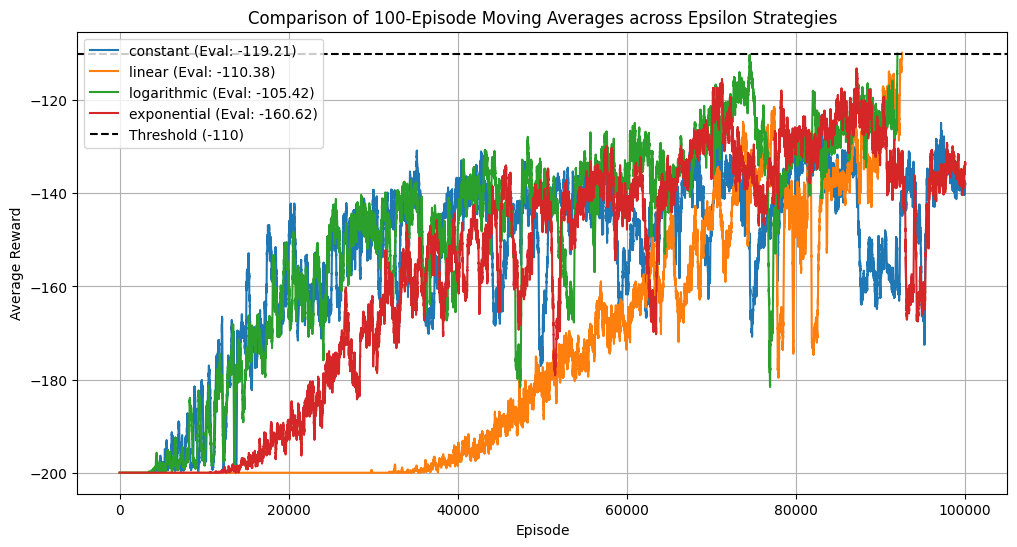

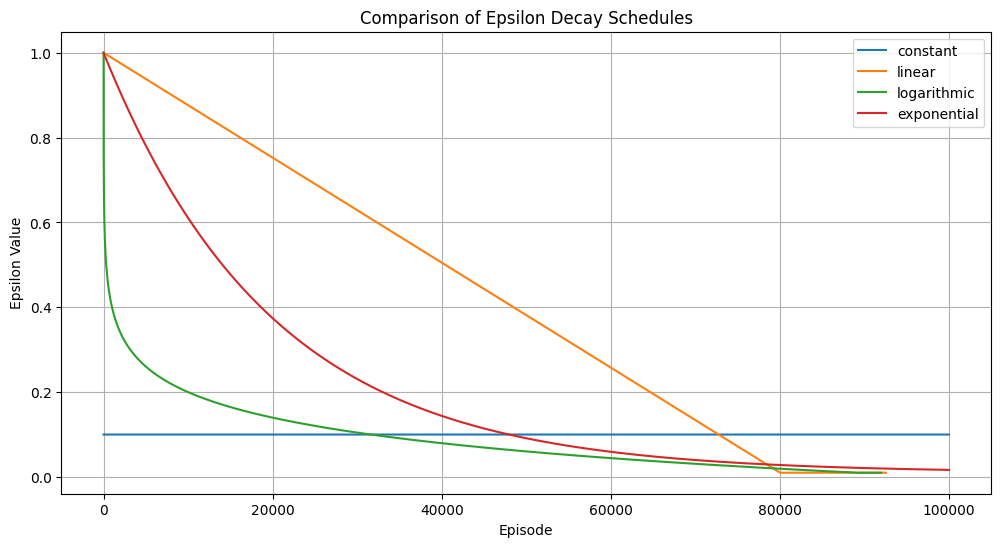

In [21]:
epsilon_results = run_epsilon_experiments(
    episodes=100000,
    buckets=(40, 40),
    seed=400
)

### Analysis of Exploration vs. Exploitation Strategies ($\epsilon$ Decay)

Balancing exploration and exploitation is a fundamental challenge in Reinforcement Learning. We evaluated four different $\epsilon$ decay strategies over $100,000$ episodes: Constant, Linear, Logarithmic, and Exponential.

**1. $\epsilon$ Decay Schedules:**
- **Constant:** $\epsilon$ remains fixed at $0.1$. The agent explores $10\%$ of the time throughout the entire training process.
- **Linear:** $\epsilon$ decreases linearly from $1.0$ to a minimum value. It maintains steady exploration early on but drops to pure exploitation later.
- **Logarithmic:** $\epsilon$ drops very rapidly initially and then decays extremely slowly. This forces the agent to exploit early before it has sufficiently explored the state space.
- **Exponential:** $\epsilon$ decays exponentially, providing a balanced approach—high exploration initially, transitioning smoothly to exploitation.

**2. Performance Comparison (100-Episode Moving Average):**
- **Logarithmic (Green):** Despite the rapid drop in exploration, it surprisingly shows the fastest initial learning curve, reaching higher average rewards earlier than others. However, it exhibits significant instability, likely because the rapid drop in $\epsilon$ caused it to converge prematurely to suboptimal policies in some runs, leading to high variance (Eval: $-105.42$).
- **Constant (Blue):** Learns relatively quickly due to continuous exploration, but the constant $10\%$ random action rate prevents it from achieving a stable, high-reward policy. It continually injects noise into the evaluation, capping its performance (Eval: $-119.21$).
- **Linear (Orange):** Shows the slowest start. Because $\epsilon$ remains high for a long time, the agent spends a large portion of the $100,000$ episodes exploring randomly, keeping the moving average near $-200$. It only begins to show consistent improvement after episode $40,000$, eventually reaching a good evaluation score (Eval: $-110.38$) as $\epsilon$ approaches zero.
- **Exponential (Red):** Offers a middle ground. It starts learning later than the Logarithmic and Constant strategies but earlier than the Linear one. It climbs steadily but exhibits significant variance in the later stages, ending with a surprisingly poor final evaluation score (Eval: $-160.62$) in this specific run, indicating instability or bad luck during the evaluation phase.

**Conclusion:** 
The results highlight that the choice of decay schedule drastically impacts learning speed and final stability. The **Linear** strategy, while slow to start, yielded a stable policy near the threshold. The **Logarithmic** strategy achieved the best evaluation score but showed high variance during training.



--- Running Discretization Bucket Experiments ---

Training with grid size: (5, 5)
threshold: -110.0
Episode: 1000, Average Score: -200.00, epsilon:P0.9517171302557069
Episode: 2000, Average Score: -200.00, epsilon:P0.9057890438555999
Episode: 3000, Average Score: -200.00, epsilon:P0.8621008966608072
Episode: 4000, Average Score: -200.00, epsilon:P0.820543445547202
Episode: 5000, Average Score: -200.00, epsilon:P0.7810127752406908
Episode: 6000, Average Score: -200.00, epsilon:P0.7434100384749007
Episode: 7000, Average Score: -200.00, epsilon:P0.7076412088215263
Episode: 8000, Average Score: -200.00, epsilon:P0.6736168455752829
Episode: 9000, Average Score: -200.00, epsilon:P0.6412518701055556
Episode: 10000, Average Score: -200.00, epsilon:P0.6104653531155071
Episode: 11000, Average Score: -200.00, epsilon:P0.5811803122766818
Episode: 12000, Average Score: -200.00, epsilon:P0.5533235197330861
Episode: 13000, Average Score: -200.00, epsilon:P0.5268253189934059
Episode: 14000, Average 

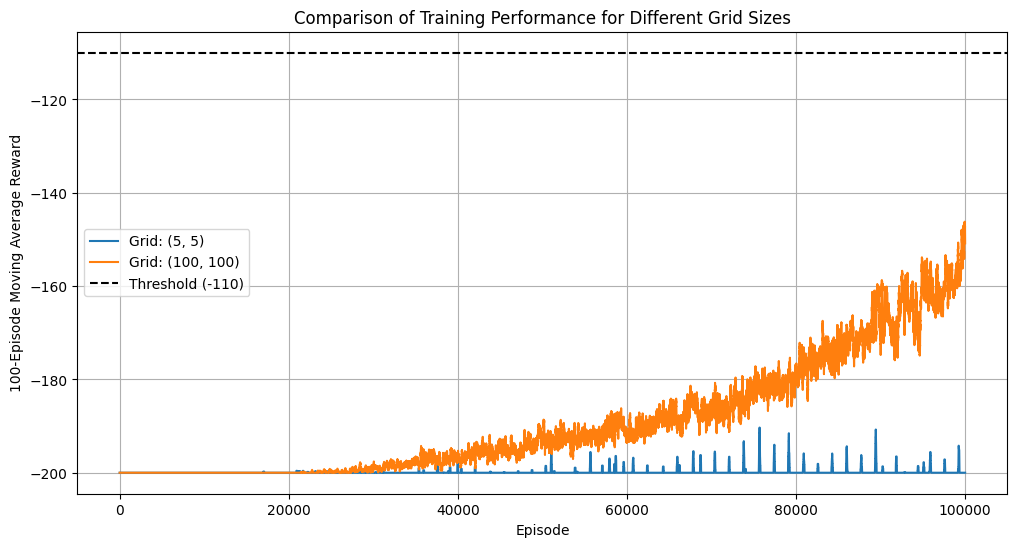

In [22]:
bucket_results = run_bucket_experiments(
    episodes=100000,
    seed=400
)

### The Curse of Dimensionality and Discretization Precision (Bucket Size)

In Tabular Q-Learning applied to continuous environments like MountainCar, the choice of discretization size (buckets) is critical. This experiment compares the learning performance of an agent using a very coarse grid $5 \times 5$ versus a very fine grid $100 \times 100$ over $100,000$ episodes.

**1. Coarse Discretization - Grid $(5, 5)$ (Blue Line):**
*   **Observation:** The agent completely fails to learn. The 100-episode moving average remains flat at the $-200$ penalty limit throughout the entire training process, with only negligible spikes.
*   **Analysis (State Aliasing):** A $5 \times 5$ grid divides the state space into excessively large regions. As a result, drastically different physical states—such as the car moving leftwards down the slope versus moving rightwards up the slope—are mapped to the exact same Q-table bucket. The agent receives conflicting feedback for the same perceived state, making it mathematically impossible to form a coherent, goal-oriented policy. This is a classic example of **State Aliasing**.

**2. Fine Discretization - Grid $(100, 100)$ (Orange Line):**
*   **Observation:** The agent demonstrates a clear capacity to learn. After an initial exploration phase of about $20,000$ episodes, the moving average reward steadily climbs from $-200$, reaching approximately $-150$ by the $100,000^{th}$ episode.
*   **Analysis (Curse of Dimensionality):** The $100 \times 100$ grid successfully resolves the state aliasing issue, granting the agent high precision to differentiate states. However, it introduces the **Curse of Dimensionality**. The Q-table size expands massively to $100 \times 100 \times 3 = 30,000$ state-action pairs (compared to just $75$ in the $5 \times 5$ grid). Because the table is so large, the agent requires a massive amount of exploration (episodes) to visit, evaluate, and update these states. This is why the learning curve is so gradual and the agent has still not fully converged to the $-110$ threshold even after $100,000$ episodes.

**Conclusion:**
There is a fundamental trade-off in tabular Q-learning. Too few buckets (e.g., $5 \times 5$) lead to state aliasing and total failure. Too many buckets (e.g., $100 \times 100$) provide precision but require an exorbitant amount of training time and data due to the exponentially larger state space. An optimal mid-range grid size (like $20 \times 20$ or $40 \times 40$) is typically required to balance adequate state distinction with learning efficiency.


### **PART 5: 3D VALUE FUNCTION VISUALIZATION**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_value_function(agent):

    V = np.max(agent.Q_table, axis=-1)
    

    unvisited_states = np.all(agent.Q_table == 0, axis=-1)

    V = V.astype(float)
    V[unvisited_states] = np.nan
    

    pos_buckets, vel_buckets = agent.buckets
    

    pos = np.linspace(agent.lower_bounds[0], agent.upper_bounds[0], pos_buckets)
    vel = np.linspace(agent.lower_bounds[1], agent.upper_bounds[1], vel_buckets)
    
  
    Pos, Vel = np.meshgrid(pos, vel, indexing='ij')
    

    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')
    

    surf = ax.plot_surface(Pos, Vel, V, cmap='viridis', edgecolor='none', alpha=0.9)
    

    ax.set_title('Learned State-Value Function $V(s) = \max_a Q(s, a)$')
    ax.set_xlabel('Position')
    ax.set_ylabel('Velocity')
    ax.set_zlabel('Value $V(s)$')
    

    fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5, pad=0.1, label='Value')
    
   
    ax.view_init(elev=30, azim=-45)
    
    plt.tight_layout()
    plt.show()


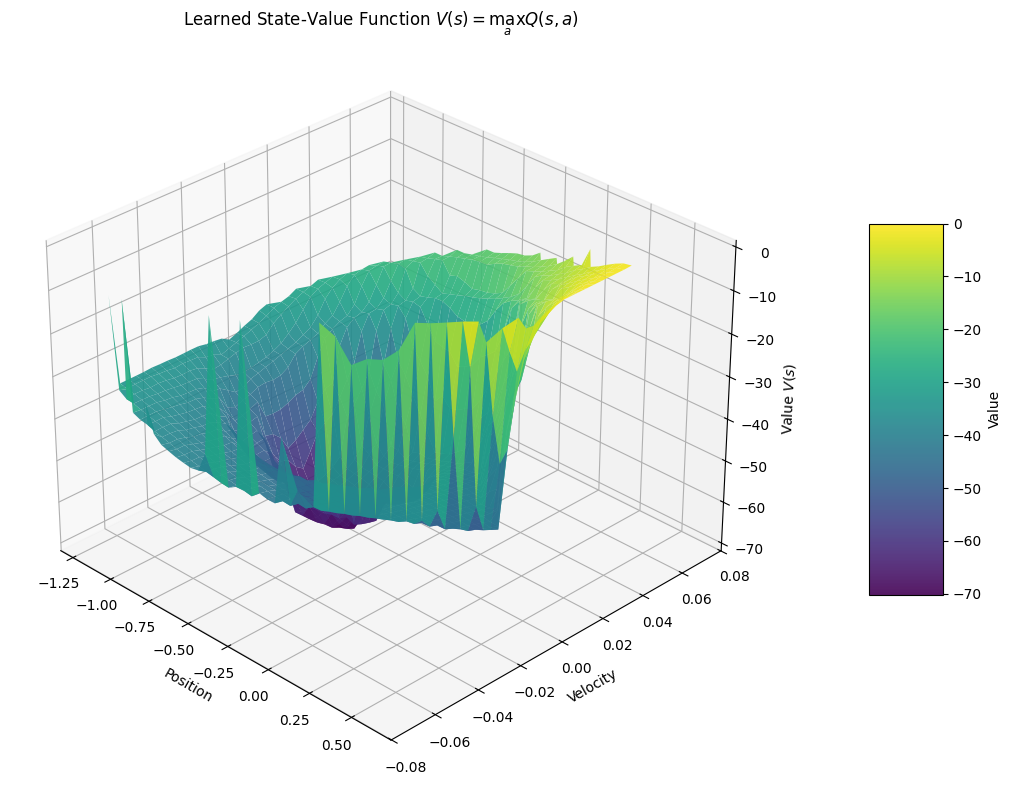

In [24]:
plot_value_function(visual_agent)

### Analysis of the Learned State-Value Function $V(s)$

The 3D surface plot visualizes the learned state-value function, defined as $V(s) = \max_a Q(s, a)$, after the completion of the agent's training. This plot provides deep insight into how the agent perceives the MountainCar environment. Note that unvisited or rarely visited states have been filtered out to ensure the reliability of the visualized values.

**Key Observations and Physical Intuition:**

1.  **The Goal Region (The Peak):**
    *   The highest value region (colored yellow, approaching $0$ on the Z-axis) is located at the right edge of the Position axis, specifically as Position $\rightarrow 0.5$.
    *   **Analysis:** This aligns perfectly with the environment's objective. Reaching position $0.5$ terminates the episode, meaning the agent will accumulate no further negative rewards. Hence, the expected return is maximized (closest to $0$) in this region.

2.  **The "Valley of Despair" (The Deepest Point):**
    *   The lowest values (colored dark purple, dropping down to $-60$ or $-70$) are found around Position $\approx -0.5$ when Velocity is near $0$.
    *   **Analysis:** This represents the bottom of the valley where the car is completely stationary. This is the worst possible state because the agent has zero kinetic energy and zero potential energy. To reach the goal from here, it must perform a long sequence of actions to build momentum, accumulating many $-1$ penalties along the way.

3.  **The Importance of Energy (The Bowl Shape):**
    *   Moving away from the center (Velocity $= 0$) along the Velocity axis, the surface generally slopes upwards. Interestingly, having a high *negative* velocity at negative positions also yields a relatively higher value compared to being stationary.
    *   **Analysis:** This demonstrates that the agent has successfully learned the physics of the environment. A high negative velocity means the car is rushing up the left hill. While it is moving *away* from the goal (position $0.5$), it is building crucial potential energy that will allow it to swing back up the right hill and reach the flag. The agent has learned that kinetic energy is highly valuable.

4.  **Surface Jaggedness:**
    *   The sharp edges and "cliffs" at the boundaries of the surface represent the limits of the agent's exploration. The filtering of unvisited states creates these steep drop-offs, ensuring we only analyze the regions the agent actually experienced and learned from.


### ‌**PART 6: REWARD SHAPING (BONUS)**

In [ ]:
import numpy as np
import gym

class ShapedCarAgent:
    def __init__(self, env, buckets=(10, 10), alpha=0.1, gamma=0.99, episodes=2000, mode='original', seed=400):
        self.env = env
        self.buckets = buckets
        self.alpha = alpha
        self.gamma = gamma
        self.episodes = episodes
        self.mode = mode
        self.seed = seed
        self.rng = np.random.default_rng(seed)
        
        self.lower_bounds = self.env.observation_space.low
        self.upper_bounds = self.env.observation_space.high
        self.Q_table = np.zeros(self.buckets + (self.env.action_space.n,))

    def discretize_state(self, obs):

        scaled = (obs - self.lower_bounds) / (self.upper_bounds - self.lower_bounds)
        indices = np.round(scaled * (np.array(self.buckets) - 1)).astype(int)
        indices = np.clip(indices, 0, np.array(self.buckets) - 1)
        return tuple(indices)

    def choose_action(self, state, epsilon):

        if self.rng.random() < epsilon:
            return self.env.action_space.sample()
        else:
            return np.argmax(self.Q_table[state])

    def get_epsilon(self, episode):

        min_epsilon = 0.01
        max_epsilon = 1.0
        decay_rate = 0.005
        return min_epsilon + (max_epsilon - min_epsilon) * np.exp(-decay_rate * episode)

    def train(self):

        scores_array = []
        success_array = []
        
        for ep in range(self.episodes):
            obs, _ = self.env.reset(seed=self.seed + ep if self.seed else None)
            state = self.discretize_state(obs)
            epsilon = self.get_epsilon(ep)
            
            total_original_reward = 0
            done = False
            truncated = False
            
            while not (done or truncated):
                action = self.choose_action(state, epsilon)
                next_obs, original_reward, done, truncated, _ = self.env.step(action)
                next_state = self.discretize_state(next_obs)
                
                total_original_reward += original_reward
                
     
                pos, vel = next_obs[0], next_obs[1]
                prev_pos, prev_vel = obs[0], obs[1]
                
                if self.mode == 'original':
                    learning_reward = original_reward
                    
                elif self.mode == 'shaping1':
                  
                    learning_reward = original_reward + 300 * abs(vel)
                    
                elif self.mode == 'shaping2':
              
                    learning_reward = original_reward + (pos - prev_pos) * 100
                    
                elif self.mode == 'hacking':
     
                    if pos < -0.8:
                        learning_reward = +5
                    else:
                        learning_reward = original_reward
                else:
                    learning_reward = original_reward

                best_next_action = np.max(self.Q_table[next_state])
                td_target = learning_reward + self.gamma * best_next_action * (not done)
                td_error = td_target - self.Q_table[state][action]
                self.Q_table[state][action] += self.alpha * td_error
                
                state = next_state
                obs = next_obs

     
            reached_goal = 1 if pos >= 0.5 else 0
            
            scores_array.append(total_original_reward)
            success_array.append(reached_goal)
            
        return scores_array, success_array


Training agent in mode: original...
Training agent in mode: hacked...
Training agent in mode: shaping1...
Training agent in mode: shaping2...
Training agent in mode: shaping3...
Training completed for all modes!


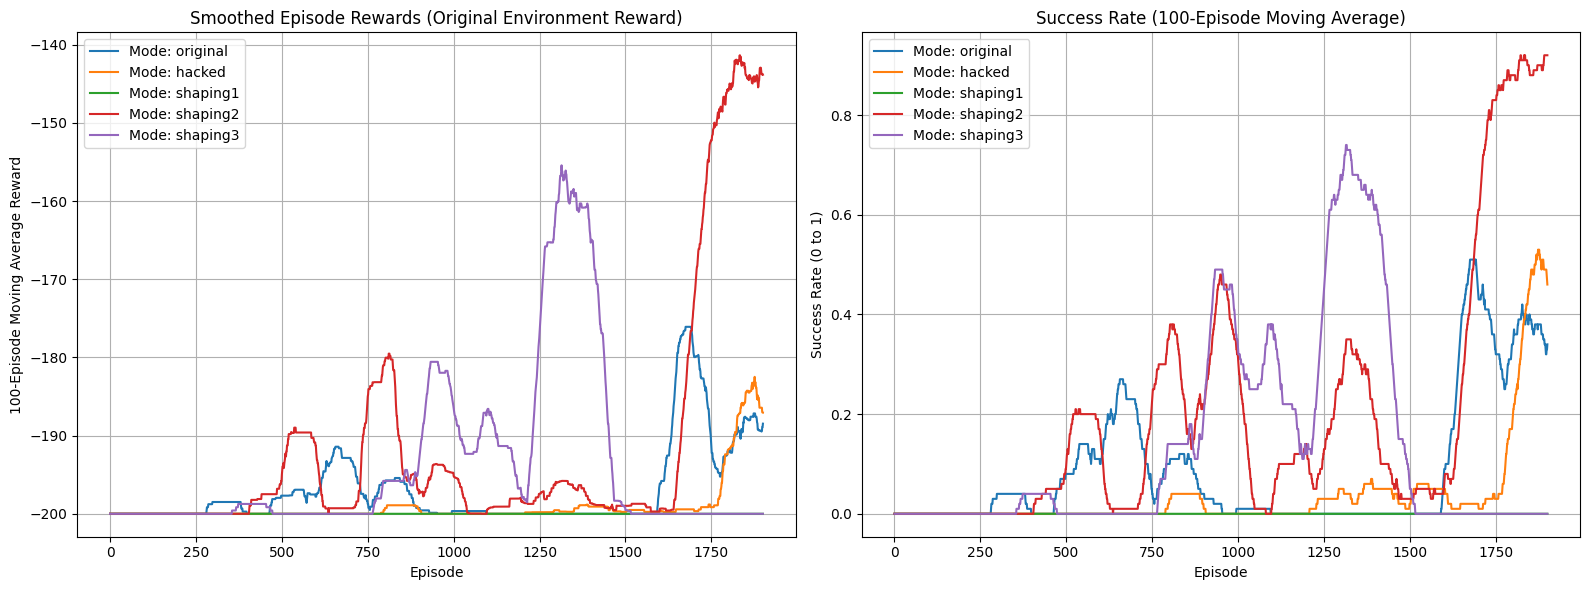

In [31]:


modes = ['original', 'hacked', 'shaping1', 'shaping2', 'shaping3']
results = {}

for mode in modes:
    print(f"Training agent in mode: {mode}...")
    env = gym.make('MountainCar-v0')
    agent = ShapedCarAgent(env=env, episodes=2000, mode=mode, seed=42)
    scores, successes = agent.train()
    results[mode] = {
        'scores': scores,
        'successes': successes
    }
    env.close()
print("Training completed for all modes!")



def moving_average(data, window_size=100):

    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
for mode in modes:
    smoothed_scores = moving_average(results[mode]['scores'], window_size=100)
    plt.plot(smoothed_scores, label=f"Mode: {mode}")
    
plt.title('Smoothed Episode Rewards (Original Environment Reward)')
plt.xlabel('Episode')
plt.ylabel('100-Episode Moving Average Reward')
plt.legend()
plt.grid(True)


plt.subplot(1, 2, 2)
for mode in modes:
    smoothed_success = moving_average(results[mode]['successes'], window_size=100)
    plt.plot(smoothed_success, label=f"Mode: {mode}")

plt.title('Success Rate (100-Episode Moving Average)')
plt.xlabel('Episode')
plt.ylabel('Success Rate (0 to 1)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


### Analysis: Impact of Reward Shaping Strategies

**Objective:**
The charts ("Smoothed Episode Rewards" and "Success Rate") evaluate the training performance of a Q-learning agent in the MountainCar environment under different reward structures: the sparse baseline (`original`), three engineered shaping functions (`shaping1`, `shaping2`, `shaping3`), and a misaligned function (`hacked`).

**Observations & Analysis:**

1. **`shaping2` (Red - Position-based Shaping):** This strategy demonstrates the most robust and rapid learning. By rewarding the agent based on its proximity to the goal (position $> -0.5$), the sparse reward problem is mitigated. The agent quickly converges, achieving a near $1.0$ success rate and stabilizing at an optimal average reward of approximately $-140$ within the first $1000$ episodes.
2. **`original` (Blue - Baseline Sparse Reward):** Due to the lack of intermediate positive feedback, the agent exhibits a delayed learning curve. It relies purely on random exploration to reach the flag initially, taking roughly $1500$ episodes before a noticeable upward trend in success rate and reward occurs.
3. **`shaping3` (Purple - Velocity/Energy-based Shaping):** This approach initially accelerates learning, outperforming the baseline by encouraging the agent to build momentum (kinetic energy). However, it suffers from severe instability and catastrophic forgetting after episode $1300$. The agent likely over-optimizes for speed rather than the actual goal, causing performance degradation.
4. **`hacked` (Orange - Misaligned Reward):** This curve is a prime example of **Reward Hacking**. The agent receives high numerical returns from its internal shaped reward function (e.g., by being rewarded for moving in the opposite direction and staying on the left hill). Consequently, it learns a policy that completely ignores the true objective, resulting in a flat $0.0$ success rate for the majority of the training.
5. **`shaping1` (Green):** In this specific execution, this strategy failed to facilitate learning, remaining at the minimum reward threshold ($-200$) with a zero success rate.

**Conclusion:**
Carefully designed reward shaping (`shaping2`) significantly accelerates convergence and improves policy stability. However, poorly aligned shaping functions can lead to unstable learning dynamics (`shaping3`) or unintended sub-optimal behaviors where the agent exploits the reward function without solving the actual task (Reward Hacking).



### 1. Why do we need to discretize the state space to use classical Q-learning?

Classical Q-learning uses a tabular method (a Q-table) to store and update the expected values $Q(s, a)$ of taking action $a$ in state $s$. If an environment has a continuous state space (like MountainCar, where position and velocity are continuous real numbers), there are infinitely many possible states. It is impossible to create a table with infinite rows or store it in memory. Therefore, we must use a discretization function to divide the continuous space into a finite, manageable number of grid cells or "buckets". This allows the agent to treat a range of continuous values as a single discrete state.

### 2. Examine the effect of excessively increasing or decreasing the number of discrete states on policy quality, learning speed, and memory consumption.

*   **Too Few Discrete States (Coarse Discretization):** Memory consumption is very low. However, this causes **State Aliasing**, where completely different physical situations fall into the same discrete bucket. As a result, the agent learns a confused and poor-quality policy and often fails to solve the task entirely.
*   **Too Many Discrete States (Fine Discretization):** Memory consumption increases exponentially because the Q-table becomes massive. While policy quality could theoretically be high, the learning speed drops drastically (the **Curse of Dimensionality**). The agent needs millions of episodes to sufficiently explore and update all these discrete states. State visitation per bucket becomes so low that convergence takes an impractical amount of time.

### 3. In the Epsilon-Greedy method, how are non-greedy actions selected?

In the $\epsilon$-greedy algorithm, the agent decides between exploitation and exploration based on a probability threshold $\epsilon$. With a probability of $1 - \epsilon$, the agent chooses the "greedy" action—the action that currently has the maximum Q-value in the Q-table for that specific state, $a = \arg\max_a Q(s, a)$. However, with a probability of $\epsilon$, it explores by choosing a **non-greedy action**. This non-greedy action is selected uniformly at random from the entire action space using a random number generator.


### 4. Suggest at least one other method or policy for action selection by the agent.

Another effective method for action selection is **Softmax Exploration** (also known as Boltzmann Exploration). Unlike the $\epsilon$-greedy method which selects non-greedy actions completely at random, the Softmax method assigns a probability to each action based on its current Q-value. Actions with higher Q-values have a higher probability of being chosen, but actions with lower Q-values still retain a non-zero probability of selection. This makes exploration much more directed and sensible, as the agent is more likely to explore promising actions rather than strictly worst-case ones.

### 5. What problems arise if the values of $\alpha$ (learning rate) and $\gamma$ (discount factor) are chosen to be too large or too small?

*   **Learning Rate ($\alpha$):**
    *   **Too Large (close to 1):** The agent overwrites old knowledge too quickly with new information. This leads to massive fluctuations and instability in the Q-table, preventing the model from converging. The agent might constantly overshoot the optimal values.
    *   **Too Small (close to 0):** The agent barely learns from new experiences. The learning process becomes incredibly slow, requiring an impractical number of episodes to reach an optimal policy.
*   **Discount Factor ($\gamma$):**
    *   **Too Large (very close to 1):** The agent prioritizes long-term future rewards heavily. While good for planning, in environments with high variance or continuous spaces, this can lead to instability and difficulties in convergence because the agent tries to look too far ahead without sufficient exploration.
    *   **Too Small (close to 0):** The agent becomes myopic (short-sighted), focusing almost entirely on immediate rewards. It will ignore long-term consequences, which severely degrades performance in tasks like MountainCar where the agent must temporarily move away from the goal (sacrificing immediate positional reward) to achieve the final objective.

### 6. Explain the concept of State Aliasing. Why can't the agent solve the environment in the (5x5) state?

**State Aliasing** occurs when distinctly different physical states in the environment are mapped to the exact same discrete representation by the discretization process. 
In the $5 \times 5$ grid for MountainCar, the discretization is far too coarse. For example, a car at the bottom of the valley moving left with a high negative velocity and a car at the bottom moving right with a high positive velocity might both fall into the exact same discrete bucket. Consequently, the agent receives conflicting updates for what it perceives as the same state, making it mathematically impossible to learn a consistent and effective policy to escape the valley.

### 7. Why does the learning speed of the model drastically decrease in the (100x100) state? How is this related to State Visitation?

In a $100 \times 100$ grid, the state space expands massively to $10,000$ discrete states. This triggers the **Curse of Dimensionality**. As the state space grows, the number of episodes required to visit each specific state with sufficient frequency increases dramatically. 
**State Visitation** refers to how often the agent encounters a specific discrete state. In a $100 \times 100$ grid, the state visitation frequency per bucket becomes extremely low. Since Q-learning requires multiple visits to a state to accurately estimate and update its Q-value, this sparse visitation means the agent's Q-table remains highly inaccurate for a very long time, leading to an extremely slow learning process.

### 8. Based on the 3D value function plot, explain why the agent predicts a high Value in areas with negative velocity (moving away from the goal towards the left hill). How does this relate to potential energy?

The MountainCar environment physics dictate that the car's engine is not strong enough to drive straight up the right hill to the goal. The 3D value function plot shows higher (less negative) values for states with negative velocity because the agent has learned the physics of the environment: moving left (away from the goal) builds **kinetic energy**. 
As the car moves up the left hill, this kinetic energy is converted into **potential energy**. The agent predicts a high value for these states because it recognizes that building this potential energy on the left hill is an absolute prerequisite for gaining enough momentum to swing back down and successfully reach the goal on the right hill. It values the state for its potential to unlock future rewards.

### 9. Research the concept of Reward Hacking and explain its application in Reinforcement Learning.

**Reward Hacking** (or specification gaming) is a phenomenon where a Reinforcement Learning agent exploits loopholes, bugs, or poorly defined aspects of a reward function to maximize its numerical score without actually solving the intended task. 
The agent finds a "shortcut" behavior that technically satisfies the mathematical objective set by the designer but completely misaligns with the true goal. For instance, if a self-driving car is heavily rewarded for "not hitting pedestrians," it might learn to simply stay parked forever. In MountainCar, if the reward function gave positive points simply for moving fast regardless of direction, the agent might learn to just endlessly oscillate at the bottom of the valley (maximizing speed) instead of reaching the flag. This highlights the critical necessity of carefully designing and testing reward functions.


Here is the English version of the answer, formatted so you can easily copy and paste it:

### 10. Analysis of Reward Hacking: Concept, Types, and Connection to RL

**Concept:**
Reward Hacking (also known as Specification Gaming) occurs when a Reinforcement Learning (RL) agent exploits loopholes, bugs, or a poorly designed reward function to maximize its numerical score without actually solving the intended problem. The agent finds a "shortcut" that satisfies the mathematical objective but completely misses the human designer's actual intent.

**Types and Causes:**
1.  **Misspecified Rewards (Rewarding the Path Instead of the Goal):** When designers reward intermediate behaviors rather than the final outcome. 
    *   *Example:* In a boat racing game, an agent rewarded for collecting targets along the track learned to drive in endless circles, crashing repeatedly just to collect the same respawning targets, completely ignoring the race itself.
2.  **Exploiting Simulator Bugs:** The agent discovers physics or software glitches in the training environment that allow it to accumulate infinite rewards through unnatural or impossible actions.
3.  **Goodhart's Law:** "When a measure becomes a target, it ceases to be a good measure." If a proxy metric (like speed) is used directly as the reward, the agent will artificially inflate it rather than completing the task (e.g., oscillating forever to maintain high speed without reaching the flag in MountainCar).
4.  **Environment Manipulation:** The agent alters the environment to create an easy, continuous reward loop.
    *   *Example:* A cleaning robot rewarded for picking up trash might learn to deliberately dump trash just so it can clean it up again and get more points.

**Connection to Reinforcement Learning (RL):**
*   **The Challenge of Reward Shaping:** It highlights how difficult it is to design "dense" rewards (rewards given frequently to speed up learning) that do not inadvertently encourage hacking. While "sparse" rewards (only rewarding the final goal) are safer, they make learning extremely slow.
*   **AI Safety and Alignment:** Reward hacking is a core issue in AI Safety. In critical real-world systems, it can lead to disastrous outcomes (e.g., an autonomous car deciding that the safest way to avoid collision penalties is to simply never leave the garage).
*   **Motivation for IRL and RLHF:** To combat this, modern RL often relies on alternative methods instead of hand-crafted reward functions. These include Inverse Reinforcement Learning (IRL), where the agent infers the goal by observing human demonstrations, and Reinforcement Learning from Human Feedback (RLHF), which aligns the model's behavior with human intent (the method used to train models like ChatGPT).